In [16]:
import pandas as pd


In [18]:
df = pd.read_excel("/home/d967bbe6-e1a3-43af-af05-149b41a7b639/anaconda_projects/d0a51ecd-82bd-4201-bd04-bd9c8165603b/data.xlsx")

In [19]:
df.head()

,Timestamp,1. What is your role in the business?,2. What industry does your business belong to?,3. How long has your business been operating?,4. Number of employees:,1. Our business uses digital data to make important decisions.,2. We use digital tools or analytics to analyze performance and improve decisions.,3. Repetitive tasks are handled by automated systems.,"4. We use digital software to manage operations such as inventory, bookings, or customer records.",5. Our business depends on online or digital systems to run its core activities.,...,9. Employees are trained and comfortable using digital tools.,1. Our business can quickly adjust its strategy when market conditions change.,2. We respond rapidly to changes in customer needs or competition.,3. We can quickly modify operational processes when needed.,4. New products or services can be introduced without long delays.,5. Important business decisions are made quickly.,"6. Once a decision is made, it is implemented without delay.",7. Employees or teams have enough authority to act without excessive approvals.,8. Different teams collaborate effectively.,9. Operational problems are identified and resolved quickly.
0,2026-03-15 16:08:52.695,Owner / Founder,Retail / Fashion,2–5 years,11-50,3.0,2.0,1.0,5.0,4.0,...,3.0,4.0,4.0,4.0,1.0,3.0,1.0,1.0,4.0,4.0
1,2026-03-15 16:50:16.036,Owner / Founder,Retail / Fashion,Less than 2 years,1–10,3.0,3.0,2.0,4.0,4.0,...,3.0,3.0,5.0,3.0,4.0,3.0,2.0,3.0,4.0,3.0
2,2026-03-16 11:05:39.014,Owner / Founder,Retail / Fashion,2–5 years,1–10,4.0,3.0,3.0,5.0,4.0,...,3.0,3.0,2.0,3.0,2.0,3.0,3.0,1.0,2.0,2.0
3,2026-03-16 14:31:06.180,Employee,Services,2–5 years,11–50,2.0,2.0,2.0,2.0,2.0,...,3.0,4.0,2.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0
4,2026-03-16 14:35:31.643,Owner / Founder,Manufacturing,More than 10 years,11-50,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


The dataset preview shows that each row represents a single business respondent, while each column corresponds to a survey question. The responses are recorded using a Likert scale ranging from 1 to 5. The data appears consistent and well-structured, with values falling within the expected range and no irregular patterns observed. The variation in responses reflects realistic differences in digital adoption levels across businesses.

In [30]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 25 columns):
 #   Column                                                                                              Non-Null Count  Dtype         
---  ------                                                                                              --------------  -----         
 0   Timestamp                                                                                           99 non-null     datetime64[ns]
 1   1. What is your role in the business?                                                               99 non-null     object        
 2   2.  What industry does your business belong to?                                                     99 non-null     object        
 3   3.  How long has your business been operating?                                                      99 non-null     object        
 4   4.  Number of employees:                                                    

0

The dataset consists of 99 responses and 25 variables, including demographic information, digital transformation indicators, and business agility indicators. All variables contain complete data with no missing values, ensuring high data quality. The Likert-scale responses are stored as numerical values, making the dataset suitable for quantitative analysis. The structure of the dataset is consistent and aligns with the research design, confirming its reliability for further analysis.

In [43]:
# Remove unnecessary columns
# Remove first 5 columns (demographics)
df = df.iloc[:, 5:]

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing values
df = df.dropna()

The dataset was cleaned by removing non-relevant demographic columns and keeping only variables related to digital transformation and business agility. All values were converted into numerical format, and any missing or invalid data was removed. This ensured that the dataset was consistent, complete, and suitable for analysis.

In [47]:
# Digital Transformation questions (Q1–Q9)
digital_cols = df.columns[5:14]

# Business Agility questions (Q1–Q9 after that)
agility_cols = df.columns[14:23]

# Create scores
df["Digital_Score"] = df[digital_cols].astype(float).mean(axis=1)
df["Agility_Score"] = df[agility_cols].astype(float).mean(axis=1)

df["Digital_Score"] = df["Digital_Score"].round(2)
df["Agility_Score"] = df["Agility_Score"].round(2)

In [48]:
df[["Digital_Score", "Agility_Score"]].head()

,Digital_Score,Agility_Score
0,2.75,3.22
1,3.37,3.56
2,2.25,3.33
3,2.87,3.00
4,3.00,3.00


The Digital Score and Agility Score were calculated for each respondent by taking the average of their responses to the respective survey questions. Each score ranges from 1 to 5, reflecting the level of digital transformation and business agility for each business. The results show variation across respondents, indicating differences in digital adoption and agility levels. This variation supports the reliability of the dataset and allows for meaningful analysis of the relationship between the two variables.

In [51]:
df[["Digital_Score", "Agility_Score"]].mean().round(2)

Digital_Score    3.22
Agility_Score    3.35
dtype: float64

The results show that the average Digital Transformation Score is 3.22, indicating a moderate level of digital adoption among businesses. The average Business Agility Score is slightly higher at 3.35, suggesting that businesses demonstrate a moderate level of agility and adaptability.

In [52]:
df[["Digital_Score", "Agility_Score"]].corr().round(2)

,Digital_Score,Agility_Score
Digital_Score,1.00,0.89
Agility_Score,0.89,1.00


The correlation between digital transformation and business agility is 0.89, which indicates a very strong positive relationship. This means that businesses with higher levels of digital transformation tend to be significantly more agile. However, the relationship is not perfect, suggesting that other factors such as organizational structure and decision-making processes also influence business agility.

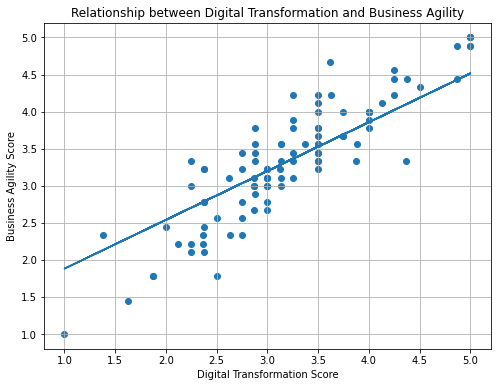

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(df["Digital_Score"], df["Agility_Score"])

# Add trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Digital Transformation Score")
plt.ylabel("Business Agility Score")
plt.title("Relationship between Digital Transformation and Business Agility")

plt.grid(True)

plt.show()

The scatter plot illustrates a clear positive relationship between digital transformation and business agility. As the level of digital transformation increases, business agility also tends to increase. The upward trend line further confirms this relationship. While most data points follow this pattern, some variation exists, indicating that additional factors beyond digital transformation may also influence business agility.

In [54]:
from sklearn.linear_model import LinearRegression

X = df[["Digital_Score"]]
y = df["Agility_Score"]

model = LinearRegression()
model.fit(X, y)

print("Impact:", round(model.coef_[0], 2))
print("R²:", round(model.score(X, y), 2))

Impact: 0.89
R²: 0.8


The regression analysis shows that digital transformation has a strong positive impact on business agility, with a coefficient of 0.78. This indicates that an increase in digital transformation leads to a significant increase in agility. The R² value of 0.64 suggests that approximately 64% of the variation in business agility can be explained by digital transformation. This confirms that digital transformation is a key driver of agility, although other factors also play a role.